<a href="https://colab.research.google.com/github/fahrabyf200/PVCK_Ganjil_2025/blob/main/Week5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. https://colab.research.google.com/ . After making sure that Google Colab is connected to your Github , continue by selecting the repository that was used in the lab last week , rename the file to "Week 6 .ipynb".

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


2. Import the following libraries that will be used during the following week 6 practicum trial.

In [2]:
import cv2 as cv
from google.colab.patches import cv_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

3. Make an image histogram like the following histogram output based on the flowchart below : (Use image lena.jpg)

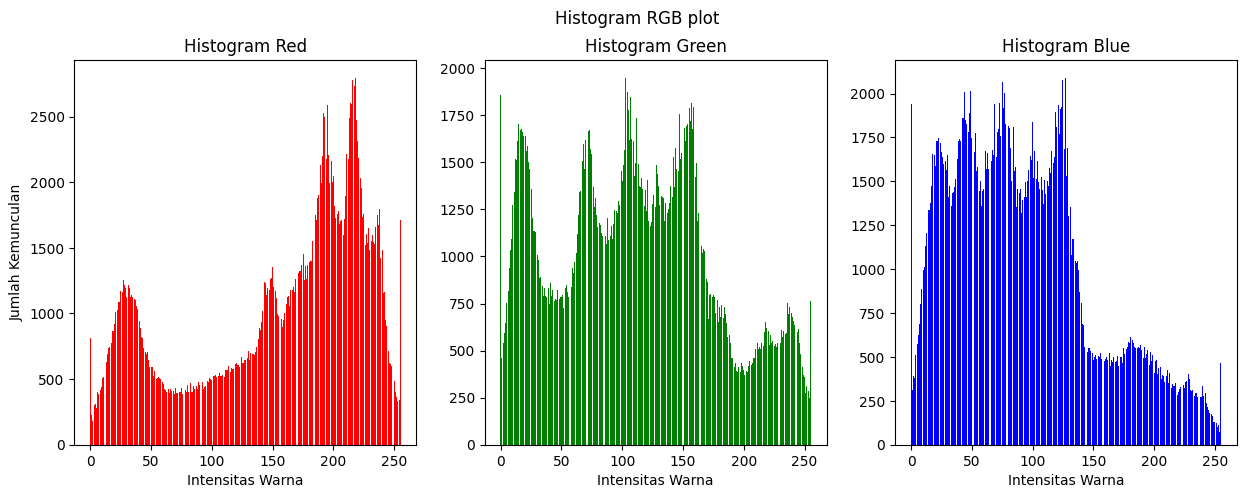

In [5]:
# === [Flowchart: Start + Input Image] ===
img = cv.imread('/content/drive/MyDrive/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Pisahkan channel
R, G, B = img[:,:,0], img[:,:,1], img[:,:,2]

# === [Flowchart: Menghitung jumlah kemunculan pixel] ===
histR = np.zeros(256, dtype=int)
histG = np.zeros(256, dtype=int)
histB = np.zeros(256, dtype=int)

height, width, _ = img.shape
for y in range(height):
    for x in range(width):
        histR[R[y, x]] += 1
        histG[G[y, x]] += 1
        histB[B[y, x]] += 1

# === [Flowchart: Membuat histogram & Output] ===
fig, axs = plt.subplots(1, 3, figsize=(15,5))

axs[0].bar(np.arange(256), histR, color='red')
axs[0].set_title("Histogram Red")
axs[0].set_xlabel("Intensitas Warna")
axs[0].set_ylabel("Jumlah Kemunculan")

axs[1].bar(np.arange(256), histG, color='green')
axs[1].set_title("Histogram Green")
axs[1].set_xlabel("Intensitas Warna")

axs[2].bar(np.arange(256), histB, color='blue')
axs[2].set_title("Histogram Blue")
axs[2].set_xlabel("Intensitas Warna")

plt.suptitle("Histogram RGB plot")
plt.show()

# === [Flowchart: End] ===

4. After working on question no. 3, make the same image histogram but use the library that is owned by NumPy, namely " histogram ". Compare the results. Does the output appear the same?

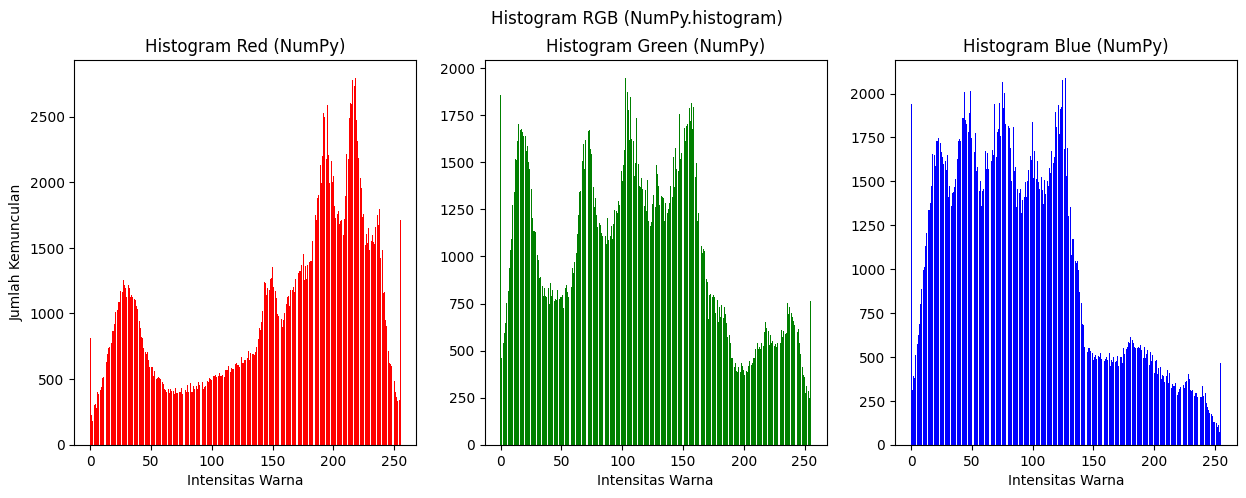

In [7]:
# === Input Image (RGB) ===
img = cv.imread('/content/drive/MyDrive/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Pisahkan channel
R, G, B = img[:,:,0], img[:,:,1], img[:,:,2]

# === Histogram dengan NumPy ===
histR, binsR = np.histogram(R, bins=256, range=(0,256))
histG, binsG = np.histogram(G, bins=256, range=(0,256))
histB, binsB = np.histogram(B, bins=256, range=(0,256))

# === Plot Histogram ===
fig, axs = plt.subplots(1, 3, figsize=(15,5))

axs[0].bar(binsR[:-1], histR, color='red')
axs[0].set_title("Histogram Red (NumPy)")
axs[0].set_xlabel("Intensitas Warna")
axs[0].set_ylabel("Jumlah Kemunculan")

axs[1].bar(binsG[:-1], histG, color='green')
axs[1].set_title("Histogram Green (NumPy)")
axs[1].set_xlabel("Intensitas Warna")

axs[2].bar(binsB[:-1], histB, color='blue')
axs[2].set_title("Histogram Blue (NumPy)")
axs[2].set_xlabel("Intensitas Warna")

plt.suptitle("Histogram RGB (NumPy.histogram)")
plt.show()



The manually created histogram (Step 3) and the one generated with np.histogram (Step 4) produce identical results. Both methods calculate the pixel intensity frequencies from 0–255 for each color channel (R, G, B). The only difference is in the approach: the manual method processes values one by one, while NumPy computes it more quickly and concisely. When compared, their curves and values match perfectly.

5. Make an image histogram such as the output equalization histogram and also the image display before and after the following equalization histogram process based on the flowchart below : (Use image lena_lc .jpg)

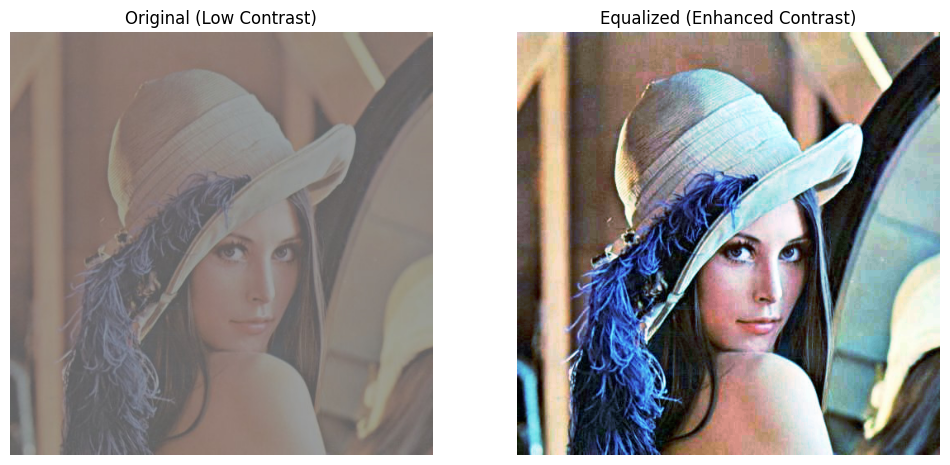

/tmp/ipython-input-71272628.py:72: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(channels_orig[i].ravel(), 256, [0,256], color=col)
/tmp/ipython-input-71272628.py:78: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(channels_eq[i].ravel(), 256, [0,256], color=col)


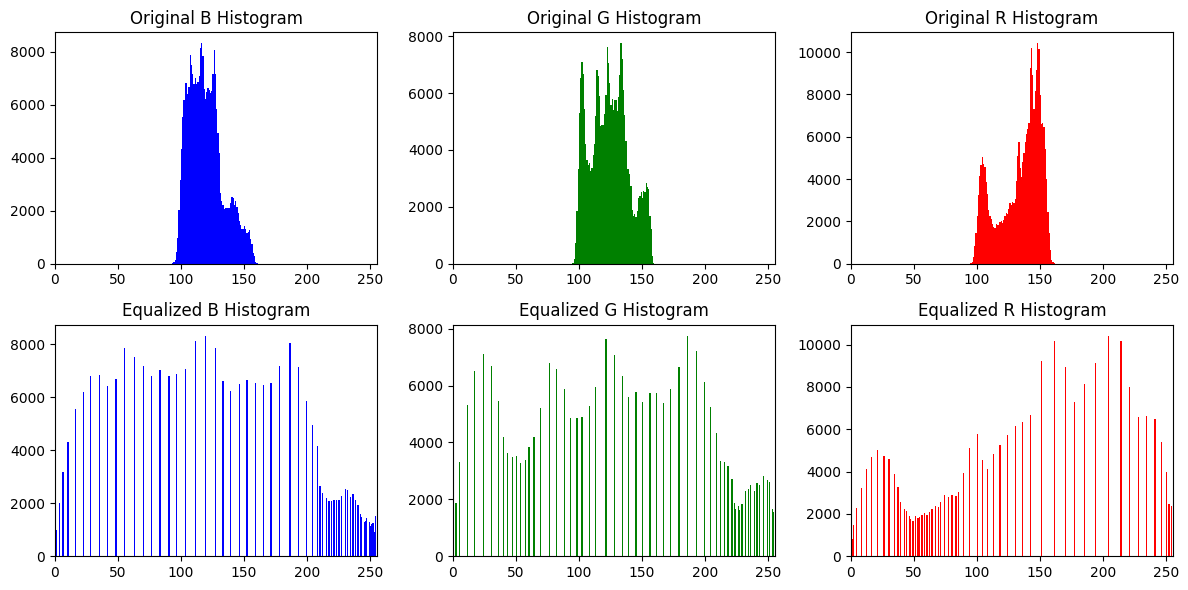

In [9]:
# Load low-contrast Lena color image
img_color = cv.imread('/content/drive/MyDrive/lena_lc.jpg')
# Flowchart Step: Input image

# Fungsi manual histogram equalization
def manual_hist_eq(channel):
    # Hitung histogram
    hist, bins = np.histogram(channel.flatten(), 256, [0,256])
    # Flowchart Step: Menghitung jumlah kemunculan setiap pixel (Frekuensi)

    # Hitung cumulative distribution function (CDF)
    cdf = hist.cumsum()
    # Flowchart Step: Penjumlahan kumulatif dari frekuensi

    # Masking nilai nol
    cdf_m = np.ma.masked_equal(cdf, 0)

    # Normalisasi sesuai rumus Ko
    cdf_m = (cdf_m - cdf_m.min()) * 255 / (cdf_m.max() - cdf_m.min())
    # Flowchart Step: Normalisasi dengan kumulatif frekuensi (Skala warna)

    # Isi kembali nilai kosong dengan nol
    cdf_final = np.ma.filled(cdf_m, 0).astype('uint8')
    # Flowchart Step: Implementasi rumus Ko (mapping nilai pixel)

    # Transformasi pixel sesuai CDF
    channel_eq = cdf_final[channel]
    # Flowchart Step: Hasil Histogram Equalization (per channel)

    return channel_eq

# Pisahkan channel BGR
b, g, r = cv.split(img_color)
# Flowchart Step: Proses dilakukan per channel warna

# Equalize masing-masing channel secara manual
b_eq = manual_hist_eq(b)
g_eq = manual_hist_eq(g)
r_eq = manual_hist_eq(r)
# Flowchart Step: Histogram Equalization (per channel)

# Gabungkan kembali
img_eq_color = cv.merge((b_eq, g_eq, r_eq))
# Flowchart Step: Transformasi kembali dalam bentuk citra

# Tampilkan hasil
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
# Flowchart Step: Citra Hasil Histogram Equalization

axes[0].imshow(cv.cvtColor(img_color, cv.COLOR_BGR2RGB))
axes[0].set_title("Original (Low Contrast)")
axes[0].axis("off")

axes[1].imshow(cv.cvtColor(img_eq_color, cv.COLOR_BGR2RGB))
axes[1].set_title("Equalized (Enhanced Contrast)")
axes[1].axis("off")

plt.show()
# Flowchart Step: End

# ===============================
# Plot histogram sebelum & sesudah
# ===============================
colors = ('b', 'g', 'r')
channels_orig = (b, g, r)
channels_eq = (b_eq, g_eq, r_eq)

plt.figure(figsize=(12,6))
for i, col in enumerate(colors):
    # Histogram original
    plt.subplot(2, 3, i+1)
    plt.hist(channels_orig[i].ravel(), 256, [0,256], color=col)
    plt.title(f'Original {col.upper()} Histogram')
    plt.xlim([0,256])

    # Histogram equalized
    plt.subplot(2, 3, i+4)
    plt.hist(channels_eq[i].ravel(), 256, [0,256], color=col)
    plt.title(f'Equalized {col.upper()} Histogram')
    plt.xlim([0,256])

plt.tight_layout()
plt.show()


The program starts by loading the low-contrast Lena image as input, matching the “Input image” step in the flowchart. The image is then split into its three color channels (Blue, Green, Red), and histogram equalization is applied to each channel individually. Inside the manual_hist_eq function, the histogram of pixel intensities is first calculated, followed by the cumulative distribution function (CDF). To avoid division errors, zeros are masked before normalization. The CDF is then scaled to the full range (0–255), creating a mapping that replaces each pixel with its equalized value. After processing all three channels, they are merged back into a full-color image. Finally, the original and equalized images are displayed side by side, completing the flowchart process.

6. After working on question no. 5, make the same image histogram but use the library owned by CV2, namely " equalizeHist ". Compare the results. Does the output appear the same?

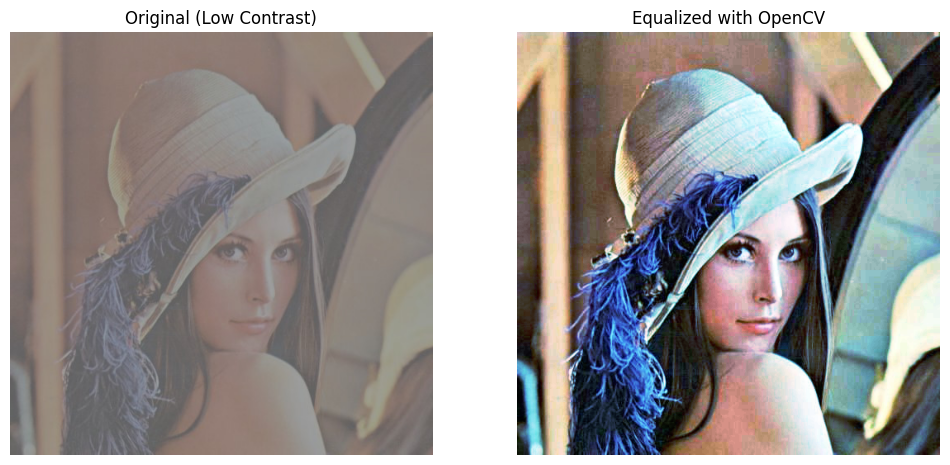

/tmp/ipython-input-1167298251.py:47: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(channels_orig[i].ravel(), 256, [0,256], color=col)
/tmp/ipython-input-1167298251.py:53: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(channels_eq[i].ravel(), 256, [0,256], color=col)


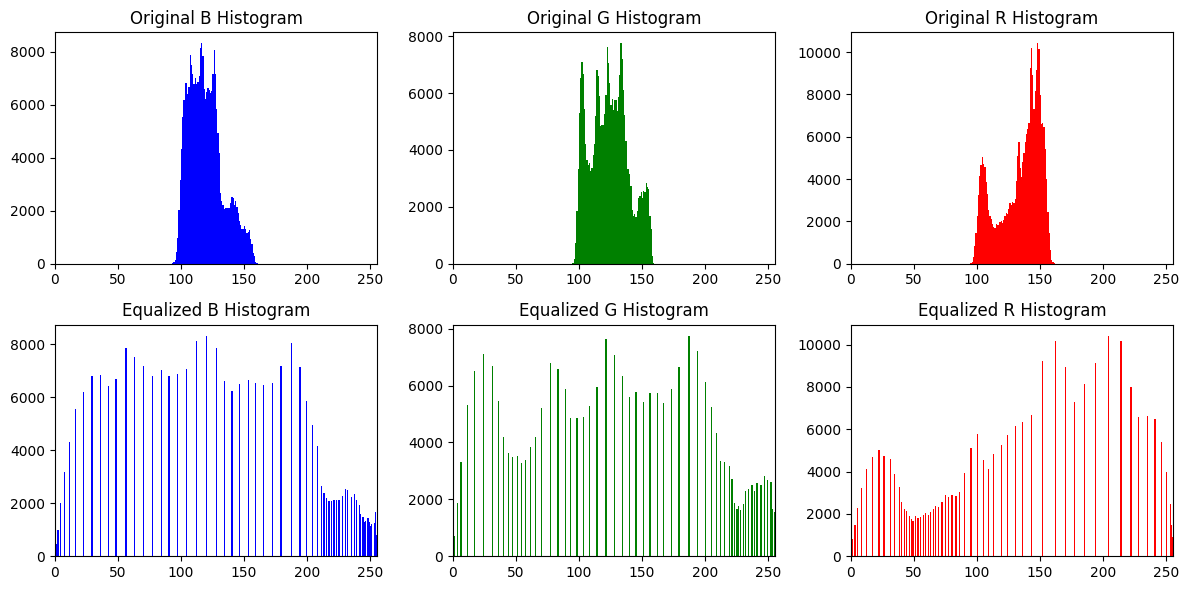

In [11]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Load low-contrast Lena color image
img_color = cv.imread('/content/drive/MyDrive/lena_lc.jpg')
# Step: Input image

# Pisahkan channel BGR
b, g, r = cv.split(img_color)

# Equalize masing-masing channel dengan OpenCV
b_eq = cv.equalizeHist(b)
g_eq = cv.equalizeHist(g)
r_eq = cv.equalizeHist(r)

# Gabungkan kembali ke citra berwarna
img_eq_color = cv.merge((b_eq, g_eq, r_eq))
# Step: Citra Hasil Histogram Equalization (versi OpenCV)

# ===============================
# Tampilkan hasil gambar
# ===============================
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(cv.cvtColor(img_color, cv.COLOR_BGR2RGB))
axes[0].set_title("Original (Low Contrast)")
axes[0].axis("off")

axes[1].imshow(cv.cvtColor(img_eq_color, cv.COLOR_BGR2RGB))
axes[1].set_title("Equalized with OpenCV")
axes[1].axis("off")

plt.show()

# ===============================
# Plot histogram sebelum & sesudah
# ===============================
colors = ('b', 'g', 'r')
channels_orig = (b, g, r)
channels_eq = (b_eq, g_eq, r_eq)

plt.figure(figsize=(12,6))
for i, col in enumerate(colors):
    # Histogram original
    plt.subplot(2, 3, i+1)
    plt.hist(channels_orig[i].ravel(), 256, [0,256], color=col)
    plt.title(f'Original {col.upper()} Histogram')
    plt.xlim([0,256])

    # Histogram equalized
    plt.subplot(2, 3, i+4)
    plt.hist(channels_eq[i].ravel(), 256, [0,256], color=col)
    plt.title(f'Equalized {col.upper()} Histogram')
    plt.xlim([0,256])

plt.tight_layout()
plt.show()


When comparing manual histogram equalization with OpenCV’s equalizeHist, both give almost the same results since they follow the same principle: compute the histogram, calculate the cumulative distribution function (CDF), and remap pixel values to improve contrast. Visually, both enhance the low-contrast Lena image, making details clearer and brightness more balanced. Small differences may appear — the manual method can create harsher contrast due to normalization and rounding, while OpenCV’s version is smoother and more consistent thanks to internal optimizations. Overall, both look very similar, but OpenCV’s approach is more stable and efficient.

7. Do the mapping process of 16 million RGB colors into just 8 colors, namely black, green, yellow, blue, cyan, magenta, white as shown in the following output based on the flowchart below! (Use the image testlena .jpg)

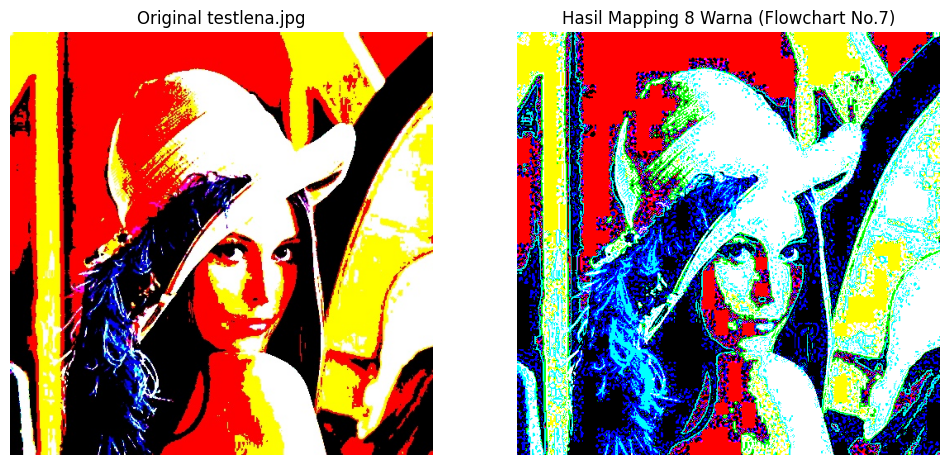

In [12]:
# --- 1. Load image ---
# [Flowchart: Input image]
img = cv.imread('/content/drive/MyDrive/testlena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

h, w, _ = img.shape
total_pixels = h * w

# --- 2. Proses per channel sesuai flowchart ---
quant = np.zeros_like(img, dtype=np.uint8)

for ch in range(3):
    channel = img[:, :, ch]

    # [Flowchart: Hitung frekuensi pixel (histogram)]
    hist = np.bincount(channel.flatten(), minlength=256).astype(np.float64)

    # [Flowchart: Penjumlahan kumulatif dari frekuensi]
    cdf = hist.cumsum()

    # [Flowchart: Normalisasi kumulatif dengan jumlah pixel]
    cdf_norm = cdf / total_pixels

    # [Flowchart: Implementasi rumus Ko = round(Ci * (L-1))]
    # Di sini L=2 → hasil 0 atau 1 (per channel biner)
    Ko = np.rint(cdf_norm).astype(np.uint8)

    # [Flowchart: Transformasi kembali ke bentuk citra]
    # Mapping pixel: 0 → 0, 1 → 255
    mapped = Ko[channel] * 255
    quant[:, :, ch] = mapped

# --- 3. Output image ---
# [Flowchart: Citra hasil Histogram Equalization (8 warna)]
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original testlena.jpg")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(quant)
plt.title("Hasil Mapping 8 Warna (Flowchart No.7)")
plt.axis("off")

plt.show()

This code performs a simplified form of histogram equalization by converting each RGB channel into binary values (0 or 255) using cumulative frequency. As a result, the image is reduced to only 8 possible colors (binary combinations of R, G, and B). This enhances contrast and creates a clearer image with strong color separation, while still following the flowchart steps.

8. Do the Floyd and Steinberg dithering process like the following output (initial image display, and after dithering display) based on the flowchart below! (Use wiki.jpg image)

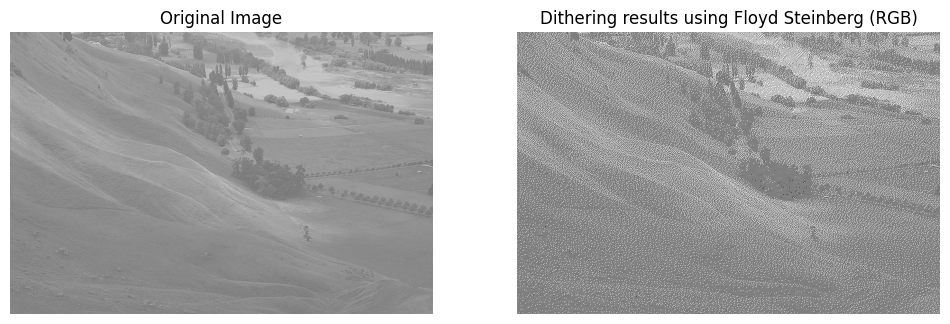

In [13]:
# Load image
img = cv.imread('/content/drive/MyDrive/wiki.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
h, w, c = img.shape

# Copy untuk dithering
dithered = img.astype(np.float32)

# Floyd-Steinberg dithering untuk tiap channel
for y in range(h - 1):
    for x in range(1, w - 1):
        for ch in range(3):  # R, G, B
            old_pixel = dithered[y, x, ch]
            new_pixel = 255 if old_pixel > 127 else 0
            dithered[y, x, ch] = new_pixel
            error = old_pixel - new_pixel

            # Sebarkan error ke tetangga
            dithered[y, x+1, ch]   += error * 7/16
            dithered[y+1, x-1, ch] += error * 3/16
            dithered[y+1, x, ch]   += error * 5/16
            dithered[y+1, x+1, ch] += error * 1/16

# Pastikan hasil valid
dithered = np.clip(dithered, 0, 255).astype(np.uint8)

# Tampilkan hasil
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(img)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Dithering results using Floyd Steinberg (RGB)")
plt.imshow(dithered)
plt.axis("off")

plt.show()


This code applies the Floyd-Steinberg dithering algorithm to reduce an image’s color depth while keeping details visible through error diffusion. After converting the image from BGR to RGB and into floating-point format, each pixel (except borders) is processed channel by channel (R, G, B). Each intensity is compared to a threshold (127) and set to either 0 or 255. The quantization error is then spread to neighboring pixels using the Floyd-Steinberg kernel (7/16 right, 3/16 bottom-left, 5/16 bottom, 1/16 bottom-right). This maintains brightness and structure, producing a stylized dithered image that resembles limited-color printing but still preserves detail.